# 3-Pulse Mach-Zehnder Interferometer

Demonstrates a $\pi/2 - \pi - \pi/2$ Mach-Zehnder atom interferometer sequence.

Pulse phases: $0$, $\phi$, $4\phi$ respectively, with $\phi$ scanned from $0$ to $2\pi$.


In [1]:
import sys

p = "2026-03-02 LMT sim"
if not any(p in s for s in sys.path):
    sys.path.append(p)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import version_info as vs

from lmt_simulation import (
    make_atom_states,
    transform_state_vector,
    propagate_states_in_borde_representation,
    pulse_interaction_in_borde_representation,
    calculate_ground_and_excited_probabilities,
    K_WAVEVECTOR,
    TRANSITION_FREQUENCY,
)



In [3]:
from scipy import constants

T_FREE = 200e-6  # Free evolution time between pulses

# Realistic rabi freq
T_PI = 45e-6
RABI_FREQ = 1 / (T_PI * 2)
MASS_ATOM = constants.atomic_mass * 87
TRANSITION_WAVELENGTH = 698e-9
# Single-photon recoil frequency: f_r = h / (2 * m * lambda^2)
F_RECOIL = constants.h / (MASS_ATOM * TRANSITION_WAVELENGTH**2)

phi_values = np.linspace(0, 2 * np.pi, 101)


In [4]:
def calc_mz_excitation_borde(
    phi,
    detuning_hz,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    m_values, positions, velocities, internal_amplitude, internal_is_ground = make_atom_states(
        initial_velocity_z=initial_velocity_z,
        c0=1,
        c1=0,
    )

    omega_laser = 2 * np.pi * (TRANSITION_FREQUENCY + detuning_hz)
    current_time = 0.0

    squiggly_amplitudes = transform_state_vector(
        m_values,
        internal_amplitude,
        internal_is_ground,
        omega_laser=omega_laser,
        t=current_time,
        z=0.0,
        vz=initial_velocity_z,
        inverse=False,
    )

    # First pi/2 pulse, phase 0
    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
        pulse_interaction_in_borde_representation(
            m_values,
            squiggly_amplitudes,
            internal_is_ground,
            positions,
            velocities,
            pulse_detuning=detuning_hz,
            t_pulse=T_PI / 2,
            pulse_rabi_freq=RABI_FREQ,
            pulse_phase=0.0,
            k_sign=+1,
            k_wavevector=K_WAVEVECTOR,
            vz=initial_velocity_z,
        )
    )
    current_time += T_PI / 2

    if time_between_pulses > 0:
        m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
            propagate_states_in_borde_representation(
                m_values,
                squiggly_amplitudes,
                internal_is_ground,
                positions,
                velocities,
                time_of_propegation=time_between_pulses,
                omega_laser=omega_laser,
                vz=initial_velocity_z,
                k_sign=+1,
                k_wavevector=K_WAVEVECTOR,
            )
        )
        current_time += time_between_pulses

    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
        pulse_interaction_in_borde_representation(
            m_values,
            squiggly_amplitudes,
            internal_is_ground,
            positions,
            velocities,
            pulse_detuning=detuning_hz,
            t_pulse=T_PI,
            pulse_rabi_freq=RABI_FREQ,
            pulse_phase=phi,
            k_sign=+1,
            k_wavevector=K_WAVEVECTOR,
            vz=initial_velocity_z,
        )
    )
    current_time += T_PI

    if time_between_pulses > 0:
        m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
            propagate_states_in_borde_representation(
                m_values,
                squiggly_amplitudes,
                internal_is_ground,
                positions,
                velocities,
                time_of_propegation=time_between_pulses,
                omega_laser=omega_laser,
                vz=initial_velocity_z,
                k_sign=+1,
                k_wavevector=K_WAVEVECTOR,
            )
        )
        current_time += time_between_pulses

    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
        pulse_interaction_in_borde_representation(
            m_values,
            squiggly_amplitudes,
            internal_is_ground,
            positions,
            velocities,
            pulse_detuning=detuning_hz,
            t_pulse=T_PI / 2,
            pulse_rabi_freq=RABI_FREQ,
            pulse_phase=4 * phi,
            k_sign=+1,
            k_wavevector=K_WAVEVECTOR,
            vz=initial_velocity_z,
        )
    )
    current_time += T_PI / 2

    internal_amplitude_final = transform_state_vector(
        m_values,
        squiggly_amplitudes,
        internal_is_ground,
        omega_laser=omega_laser,
        t=current_time,
        z=0.0,
        vz=initial_velocity_z,
        inverse=True,
    )

    ground_prob, excited_prob = calculate_ground_and_excited_probabilities(
        m_values,
        internal_amplitude_final,
        internal_is_ground,
    )

    total_prob = ground_prob + excited_prob
    return excited_prob / total_prob


# Simulate single zero-velocity atom
excitation_fractions = np.array([
    calc_mz_excitation_borde(phi, detuning_hz=F_RECOIL / 2)
    for phi in phi_values
])


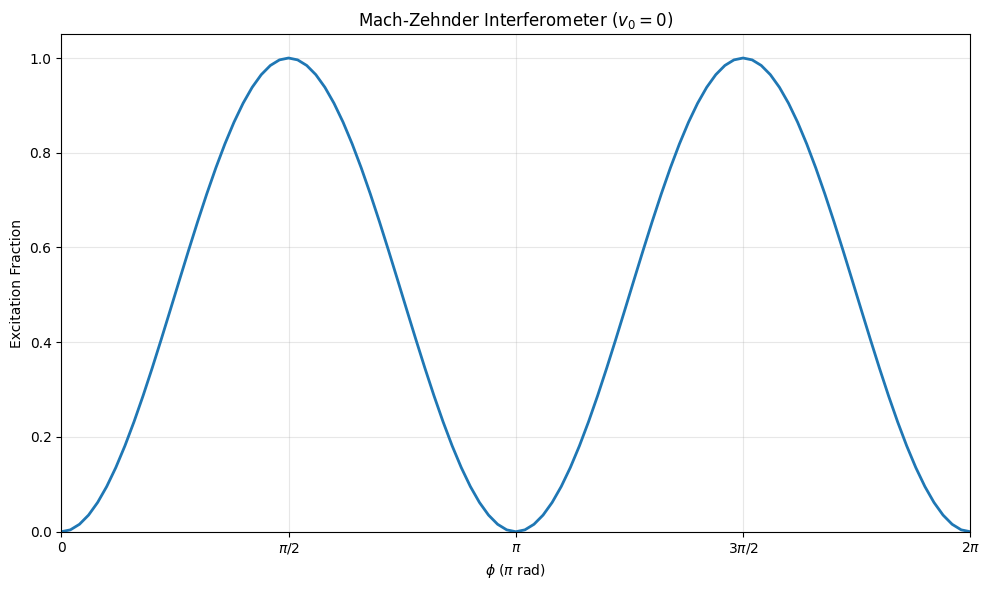

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(phi_values / np.pi, excitation_fractions, color="tab:blue", lw=2)

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Excitation Fraction")
ax.set_title("Mach-Zehnder Interferometer ($v_0 = 0$)")
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
vs.tag_plot(small=True)
fig.tight_layout()
